## Neural Network

Uses the same data split and evaluation pipeline for the classical models

## Steps

1. Load the saved TF-IDF features and trained neural model.
2. Recompute training, validation, and test metrics.
3. Inspect the training history and saved learning curves.
4. Compare the neural network with the classical baselines.

## Setting Up Project Root and Import Paths

In [2]:
import sys
import os
from pathlib import Path

# Add parent directory to path so src module is importable
# Works in local Jupyter, Google Colab, and other notebook environments
notebook_dir = Path.cwd()
if notebook_dir.name == 'notebooks' or 'notebooks' in str(notebook_dir):
    project_root = notebook_dir.parent
elif (notebook_dir / 'notebooks').exists():
    project_root = notebook_dir
else:
    project_root = Path.cwd()

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Optional: for Google Colab, mount drive if needed (uncomment if using Colab)
# from google.colab import drive
# drive.mount('/content/drive')
# project_root = Path('/content/drive/MyDrive/ML Project')  # adjust path as needed

print(f"Project root: {project_root}")
print(f"sys.path[0]: {sys.path[0]}")

Project root: /Users/shadiptopranto/Desktop/ML Project
sys.path[0]: /Users/shadiptopranto/Desktop/ML Project


## Setting Up Paths, Imports, and Display Options for Neural Model Evaluation

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

from src.features import load_vectorizer, transform_texts
from src.nn_model import load_sparse_mlp

# Use project_root from setup cell, or resolve relative to notebook
try:
    root = project_root  # set in setup cell above
except NameError:
    root = Path('..').resolve()

data_dir = root / 'data' / 'processed'
models_dir = root / 'models'
results_dir = root / 'results'
figures_dir = results_dir / 'figures'

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 140)

## Loading Vectorizer, Neural Model, and Dataset Splits

In [4]:
vectorizer = load_vectorizer(models_dir / 'tfidf_vectorizer.pkl')
neural_model = load_sparse_mlp(models_dir / 'neural_mlp.pkl')

split_frames = {}
for split_name in ['train', 'validation', 'test']:
    frame = pd.read_csv(data_dir / f'{split_name}_data.csv')
    frame['cleaned_text'] = frame['cleaned_text'].fillna('').astype(str)
    split_frames[split_name] = frame

split_frames['train'].head(2)

,text,class,cleaned_text
0,"I cant find motive to live, it feels worthless.Suicide is considered very sinful in my culture and religious beliefs...",suicide,i cant find motive to live it feels worthlesssuicide is considered very sinful in my culture and religious beliefs s...
1,"LettersI don't know what I'm going to do, but I think I might start writing letters to my loved ones in case. I feel...",suicide,lettersi dont know what im going to do but i think i might start writing letters to my loved ones in case i feel lik...


## Neural Model Performance on All Dataset Splits

In [5]:
metrics_rows = []
for split_name, frame in split_frames.items():
    X_split = transform_texts(frame['cleaned_text'], vectorizer)
    y_true = frame['class'].values
    y_pred = neural_model.predict(X_split)
    y_score = neural_model.predict_positive_proba(X_split)

    metrics_rows.append({
        'split': split_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred, pos_label='suicide'),
        'roc_auc': roc_auc_score((y_true == 'suicide').astype(int), y_score),
    })

metrics_df = pd.DataFrame(metrics_rows)
metrics_df

,split,accuracy,f1,roc_auc
0,train,0.952256,0.951925,0.988555
1,validation,0.939417,0.938838,0.983240
2,test,0.942003,0.941483,0.984337


## Training History

In [6]:
history_df = pd.read_csv(results_dir / 'neural_training_history.csv')
history_df

,epoch,train_loss,val_loss,train_f1,val_f1
0,1,0.140910,0.169962,0.951925,0.938838
1,2,0.124016,0.172562,0.960790,0.938310
2,3,0.112020,0.177385,0.965337,0.937378
3,4,0.098564,0.184987,0.971636,0.937333
4,5,0.082032,0.197345,0.977871,0.936818


## Neural MLP Training and Validation Loss Curves

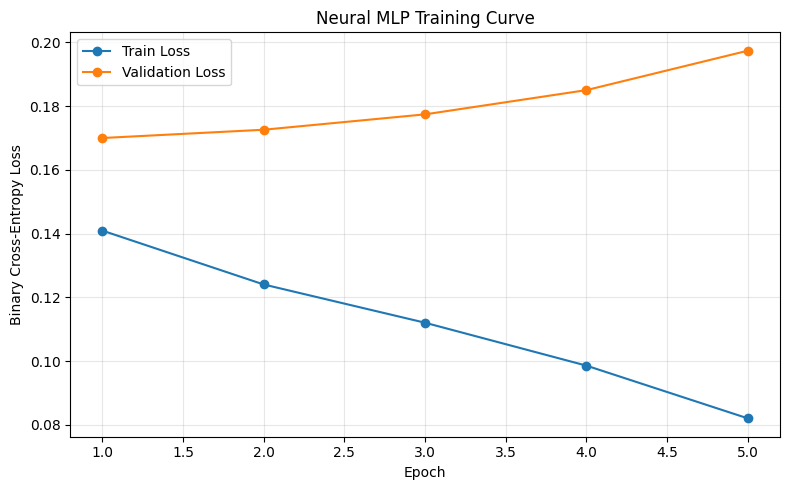

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_df['epoch'], history_df['train_loss'], marker='o', label='Train Loss')
ax.plot(history_df['epoch'], history_df['val_loss'], marker='o', label='Validation Loss')
ax.set_title('Neural MLP Training Curve')
ax.set_xlabel('Epoch')
ax.set_ylabel('Binary Cross-Entropy Loss')
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## Comparison With Classical Models

In [8]:
comparison_df = pd.read_csv(results_dir / 'comparison_results.csv')
comparison_df.sort_values(by='f1', ascending=False).reset_index(drop=True)

,model,accuracy,precision,recall,f1
0,voting_classifier,0.941270,0.944295,0.937866,0.941070
1,calibrated_svm,0.940495,0.948023,0.932092,0.939990
2,linear_svm,0.939762,0.947475,0.931144,0.939239
3,logistic_regression,0.938168,0.946753,0.928559,0.937568
4,naive_bayes,0.912013,0.879264,0.955188,0.915655
